# Enrichments

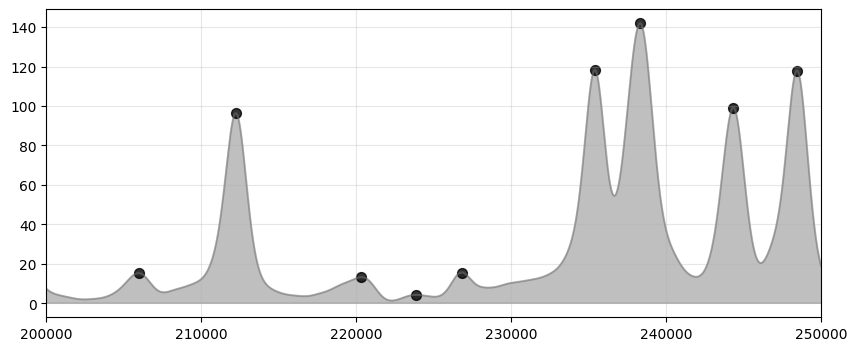

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bio
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
%matplotlib inline


# ── Global Values ──────────────────────────────────────────────────────────────────

# Chromosomes
CHROMS = [
    'chrI',
    'chrII',
    'chrIII',
    'chrIV',
    'chrV',
    'chrVI',
    'chrVII',
    'chrVIII',
    'chrIX',
    'chrX',
    'chrXI',
    'chrXII',
    'chrXIII',
    'chrXIV',
    'chrXV',
    'chrXVI'
]


# Nucleosomes :
DATA_NUC = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/mono.midpoint.bigwig"

# Cohesin :
DATA_COHE = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/GSM4577764_Mcd1p_WT.bigwig"


# ── Window ──────────────────────────────────────────────────────────────────

# Reading Data:
data = DATA_COHE

# Choosing the region of reads
chrom   = 'chrII'
df1     = bioframe.read_bigwig(data, chrom)
xlims   = [200_000, 250_000]
SIGMA   = 500


# ── Calculations ──────────────────────────────────────────────────────────────────

# Note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')
enrichment_uniform = f(pos_uniform)

# Smoothing -> sigma is the smooting parameter
# Based on the biological value : typically, beatween each car there is between 10 and 20 kb
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)

# Finding Peaks using Scipy
# With a minimum height of min_h and a minimum distance of min_d between peaks
min_h = 1
min_d = 10
prominence = 0.050
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)


# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)
plt.grid(True, which="both", alpha=0.30)
plt.show()

In [2]:
# ── Calculating File ──────────────────────────────────────────────────────────────────

# Create a dataframe with the peaks heights and positions
df_CARs = []
for chrom in CHROMS[:]:
    df1 = bioframe.read_bigwig(data, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    df_CARs.append(chrom_df)
df_CARs = pd.concat(df_CARs, ignore_index=True)

# Condition on the detection of CARs !
CAR_strenght = 10

# Create df for cooltools off-diagonal plots using only NN CARS
df_CARs_NN=[]
for chrom in CHROMS[:]:
    df_CARs_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])
    chrom_mask = (df_CARs["chrom"] == chrom) & (df_CARs["CAR strength"] > CAR_strenght)

    df_CARs_NN_chrom["chrom1"]=list(df_CARs[chrom_mask][:-1]["chrom"])
    df_CARs_NN_chrom["chrom2"]=list(df_CARs[chrom_mask][1:]["chrom"])

    df_CARs_NN_chrom["start1"]=list(df_CARs[chrom_mask][:-1]["start"])
    df_CARs_NN_chrom["start2"]=list(df_CARs[chrom_mask][1:]["start"]) 

    df_CARs_NN_chrom["end1"]=list(df_CARs[chrom_mask][:-1]["end"])
    df_CARs_NN_chrom["end2"]=list(df_CARs[chrom_mask][1:]["end"])

    df_CARs_NN_chrom["CAR strength1"]=list(df_CARs[chrom_mask][:-1]["CAR strength"])
    df_CARs_NN_chrom["CAR strength2"]=list(df_CARs[chrom_mask][1:]["CAR strength"])

    df_CARs_NN.append(df_CARs_NN_chrom)
    
df_CARs_NN = pd.concat(df_CARs_NN, ignore_index=True)


# ── Saving File ──────────────────────────────────────────────────────────────────
df_CARs_NN.to_parquet("df_CARs_NN.parquet", index=False)

In [3]:
df_CARs_NN

,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2
0,chrI,28420.0,28420.0,14.056107,chrI,30965.0,30965.0,14.612889
1,chrI,30965.0,30965.0,14.612889,chrI,51741.0,51741.0,111.591820
2,chrI,51741.0,51741.0,111.591820,chrI,65253.0,65253.0,35.773094
3,chrI,65253.0,65253.0,35.773094,chrI,74508.0,74508.0,13.379583
4,chrI,74508.0,74508.0,13.379583,chrI,80364.0,80364.0,94.203125
...,...,...,...,...,...,...,...,...
1240,chrXVI,893788.0,893788.0,31.501162,chrXVI,909641.0,909641.0,21.759375
1241,chrXVI,909641.0,909641.0,21.759375,chrXVI,917004.0,917004.0,52.045046
1242,chrXVI,917004.0,917004.0,52.045046,chrXVI,921110.0,921110.0,11.645302
1243,chrXVI,921110.0,921110.0,11.645302,chrXVI,930712.0,930712.0,25.897526


# HiC

INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrI', 'chrI'): 11
INFO:coolpuppy:('chrIII', 'chrIII'): 19
INFO:coolpuppy:('chrVI', 'chrVI'): 14
INFO:coolpuppy:('chrIX', 'chrIX'): 32
INFO:coolpuppy:('chrX', 'chrX'): 58
INFO:coolpuppy:('chrXI', 'chrXI'): 44
INFO:coolpuppy:('chrVIII', 'chrVIII'): 35
INFO:coolpuppy:('chrV', 'chrV'): 37
INFO:coolpuppy:('chrXIV', 'chrXIV'): 51
INFO:coolpuppy:('chrXIII', 'chrXIII'): 62
INFO:coolpuppy:('chrXVI', 'chrXVI'): 66
INFO:coolpuppy:('chrII', 'chrII'): 56
INFO:coolpuppy:('chrXV', 'chrXV'): 77
INFO:coolpuppy:('chrIV', 'chrIV'): 106
INFO:coolpuppy:('chrXII', 'chrXII'): 73
INFO:coolpuppy:('chrVII', 'chrVII'): 74
INFO:coolpuppy:Total number of piled up windows: 815


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,count.avg,count.avg.smoothed
0,chrM,chrM,0,0,NaN,86,86,NaN,NaN,NaN
1,chrM,chrM,1,1000,0.0,85,85,NaN,NaN,0.0
2,chrM,chrM,2,2000,0.0,84,84,0.0,0.0,0.0
3,chrM,chrM,3,3000,0.0,83,83,0.0,0.0,0.0
4,chrM,chrM,4,4000,0.0,82,82,0.0,0.0,0.0


Index(['chrom', 'start', 'end'], dtype='object')


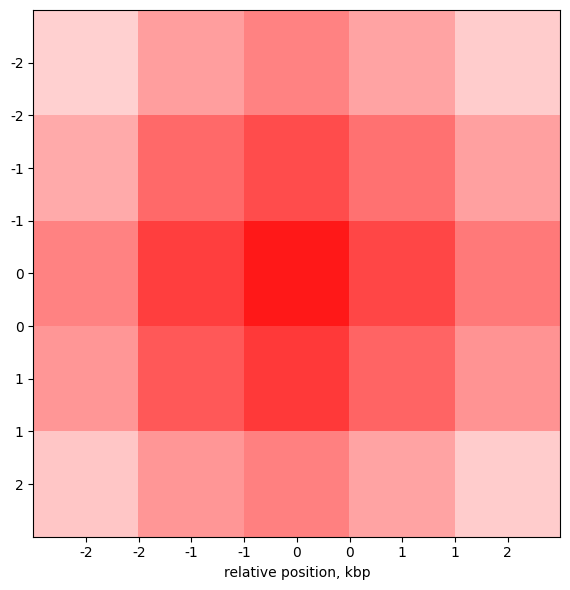

In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Global Values ──────────────────────────────────────────────────────────────────

# Window size NB this is also the minimal distance between CARs that will be considered
# If you consider too many low strength CARs that may be a problem
RESOLUTION  = 1000
FLANK       = 2_000 
ROOT        = "/home/nicolas/Documents/Workspace/nucleo/"


# ── Reading ──────────────────────────────────────────────────────────────────

clr = cooler.Cooler(
    ROOT +  "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

df_CARs_NN = pd.read_parquet(
    ROOT + "notebooks/figures/article_1/df_CARs_NN.parquet"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)

pup = cpp_pileup(
    clr,
    df_CARs_NN,
    features_format="bedpe",
    flank=FLANK,
    view_df=view_df,
    expected_df=cvd,
    expected_value_col="count.avg.smoothed",
    clr_weight_name=None,
    nproc=8,
)


# ── Plot ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))
mtx=pup.loc[0, 'data']
im=ax.imshow(
    np.log2((mtx)),
    cmap='bwr',
    vmin=-1,
    vmax=1,
interpolation='none')

ticks_pixels = np.linspace(0, FLANK*2//RESOLUTION,9)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*RESOLUTION//1000).astype(int)
ax.set(
    xticks=ticks_pixels,
    xticklabels=ticks_kbp,
    yticks=ticks_pixels,
    yticklabels=ticks_kbp,
    xlabel='relative position, kbp'
    )
        
fig.tight_layout()


# ── Print ──────────────────────────────────────────────────────────────────

display(cvd.head())
print(clr.bins().columns)

In [5]:
df_CARs_NN

,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2
0,chrI,28420.0,28420.0,14.056107,chrI,30965.0,30965.0,14.612889
1,chrI,30965.0,30965.0,14.612889,chrI,51741.0,51741.0,111.591820
2,chrI,51741.0,51741.0,111.591820,chrI,65253.0,65253.0,35.773094
3,chrI,65253.0,65253.0,35.773094,chrI,74508.0,74508.0,13.379583
4,chrI,74508.0,74508.0,13.379583,chrI,80364.0,80364.0,94.203125
...,...,...,...,...,...,...,...,...
1240,chrXVI,893788.0,893788.0,31.501162,chrXVI,909641.0,909641.0,21.759375
1241,chrXVI,909641.0,909641.0,21.759375,chrXVI,917004.0,917004.0,52.045046
1242,chrXVI,917004.0,917004.0,52.045046,chrXVI,921110.0,921110.0,11.645302
1243,chrXVI,921110.0,921110.0,11.645302,chrXVI,930712.0,930712.0,25.897526


# Nucleosomes

In [6]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
from pathlib import Path
import polars as pl


# ── DataFrames ──────────────────────────────────────────────────────────────────

# CARs
df_CARs_NN = pl.read_parquet("df_CARs_NN.parquet")

# Nucleosomes
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_NUCLEOSOMES = pl.read_csv(
    root,
    separator="\t"
)


# ── Analysis ──────────────────────────────────────────────────────────────────

# Adding New Columns
df_CARs_NUCLEO = df_CARs_NN.with_columns(
    pl.lit(None).alias("smt_pos"),
    pl.lit(None).alias("smt_value"),
    pl.lit(None).alias("fuzziness_score"),
    pl.lit(None).alias("NRLs")
)

# DataFrame Only With Positions for Filter
df_POS = df_NUCLEOSOMES.with_columns(
    pl.col("smt_pos").cast(pl.Float64)
)

# Adding a CAR Index
if "car_idx" not in df_CARs_NUCLEO.columns:
    df_CARs_NUCLEO = df_CARs_NUCLEO.with_row_index("car_idx")

# Filters
# joined a maintenant : car_idx, chrom1, start1, start2,
# + TOUTES les colonnes de df_NUCLEOSOMES (smt_pos, smt_value, fuzziness_score, etc.)
# → une ligne par (CAR, nucléosome) qui match
cars = df_CARs_NUCLEO.select(["car_idx", "chrom1", "start1", "start2"])
joined = cars.join_where(
    df_POS,
    pl.col("chr") == pl.col("chrom1"),
    pl.col("smt_pos") > pl.col("start1"),
    pl.col("smt_pos") < pl.col("start2"),
)


# ── Joining by CAR ──────────────────────────────────────────────

grouped = (
    joined
    .sort(["car_idx", "smt_pos"])
    .group_by("car_idx", maintain_order=True)
    .agg(
        pl.col("smt_pos"),
        pl.col("smt_value"),
        pl.col("fuzziness_score"),
        pl.col("smt_pos").diff().slice(1).alias("NRLs"),
    )
)

# Fusion finale : on remplace les colonnes placeholders (None)
df_CARs_NUCLEO = (
    df_CARs_NUCLEO
    .drop(["smt_pos", "smt_value", "fuzziness_score", "NRLs"])
    .join(grouped, on="car_idx", how="left")
)


# ── Median Values ──────────────────────────────────────────────

df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    pl.col("smt_pos").fill_null([]),
    pl.col("smt_value").fill_null([]),
    pl.col("fuzziness_score").fill_null([]),
    pl.col("NRLs").fill_null([]),
).with_columns(
    pl.col("NRLs").list.median().alias("NRLs_median"),
    pl.col("fuzziness_score").list.median().alias("fuzziness_median"),
    pl.col("smt_value").list.median().alias("smt_median"),
    pl.col("smt_value").list.len().alias("N_nuc"),
    (pl.col("smt_value").list.sum() / (pl.col("start2") - pl.col("start1"))).alias("smt_density"),
)


# ── Save ──────────────────────────────────────────────────
print(df_CARs_NUCLEO)
df_CARs_NUCLEO.write_parquet("df_CARs_NUCLEO.parquet")

shape: (1_245, 18)
┌─────────┬────────┬──────────┬──────────┬───┬──────────────────┬────────────┬───────┬─────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ fuzziness_median ┆ smt_median ┆ N_nuc ┆ smt_density │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ ---              ┆ ---        ┆ ---   ┆ ---         │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ f64              ┆ f64        ┆ u32   ┆ f64         │
╞═════════╪════════╪══════════╪══════════╪═══╪══════════════════╪════════════╪═══════╪═════════════╡
│ 0       ┆ chrI   ┆ 28420.0  ┆ 28420.0  ┆ … ┆ 53.237259        ┆ 560.0      ┆ 14    ┆ 22.632613   │
│ 1       ┆ chrI   ┆ 30965.0  ┆ 30965.0  ┆ … ┆ 52.414125        ┆ 21840.0    ┆ 119   ┆ 129.195225  │
│ 2       ┆ chrI   ┆ 51741.0  ┆ 51741.0  ┆ … ┆ 50.88625         ┆ 24640.0    ┆ 78    ┆ 150.171699  │
│ 3       ┆ chrI   ┆ 65253.0  ┆ 65253.0  ┆ … ┆ 55.314382        ┆ 17040.0    ┆ 52    ┆ 97.832523   │
│ 4       ┆ chrI   ┆ 74508.0  ┆ 74508.0  ┆ … ┆ 54.134448        ┆ 22720.

# Analysing by Categories

shape: (1_245, 18)
┌─────────┬────────┬──────────┬──────────┬───┬──────────────────┬────────────┬───────┬─────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ fuzziness_median ┆ smt_median ┆ N_nuc ┆ smt_density │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ ---              ┆ ---        ┆ ---   ┆ ---         │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ f64              ┆ f64        ┆ u32   ┆ f64         │
╞═════════╪════════╪══════════╪══════════╪═══╪══════════════════╪════════════╪═══════╪═════════════╡
│ 0       ┆ chrI   ┆ 28420.0  ┆ 28420.0  ┆ … ┆ 53.237259        ┆ 560.0      ┆ 14    ┆ 22.632613   │
│ 1       ┆ chrI   ┆ 30965.0  ┆ 30965.0  ┆ … ┆ 52.414125        ┆ 21840.0    ┆ 119   ┆ 129.195225  │
│ 2       ┆ chrI   ┆ 51741.0  ┆ 51741.0  ┆ … ┆ 50.88625         ┆ 24640.0    ┆ 78    ┆ 150.171699  │
│ 3       ┆ chrI   ┆ 65253.0  ┆ 65253.0  ┆ … ┆ 55.314382        ┆ 17040.0    ┆ 52    ┆ 97.832523   │
│ 4       ┆ chrI   ┆ 74508.0  ┆ 74508.0  ┆ … ┆ 54.134448        ┆ 22720.

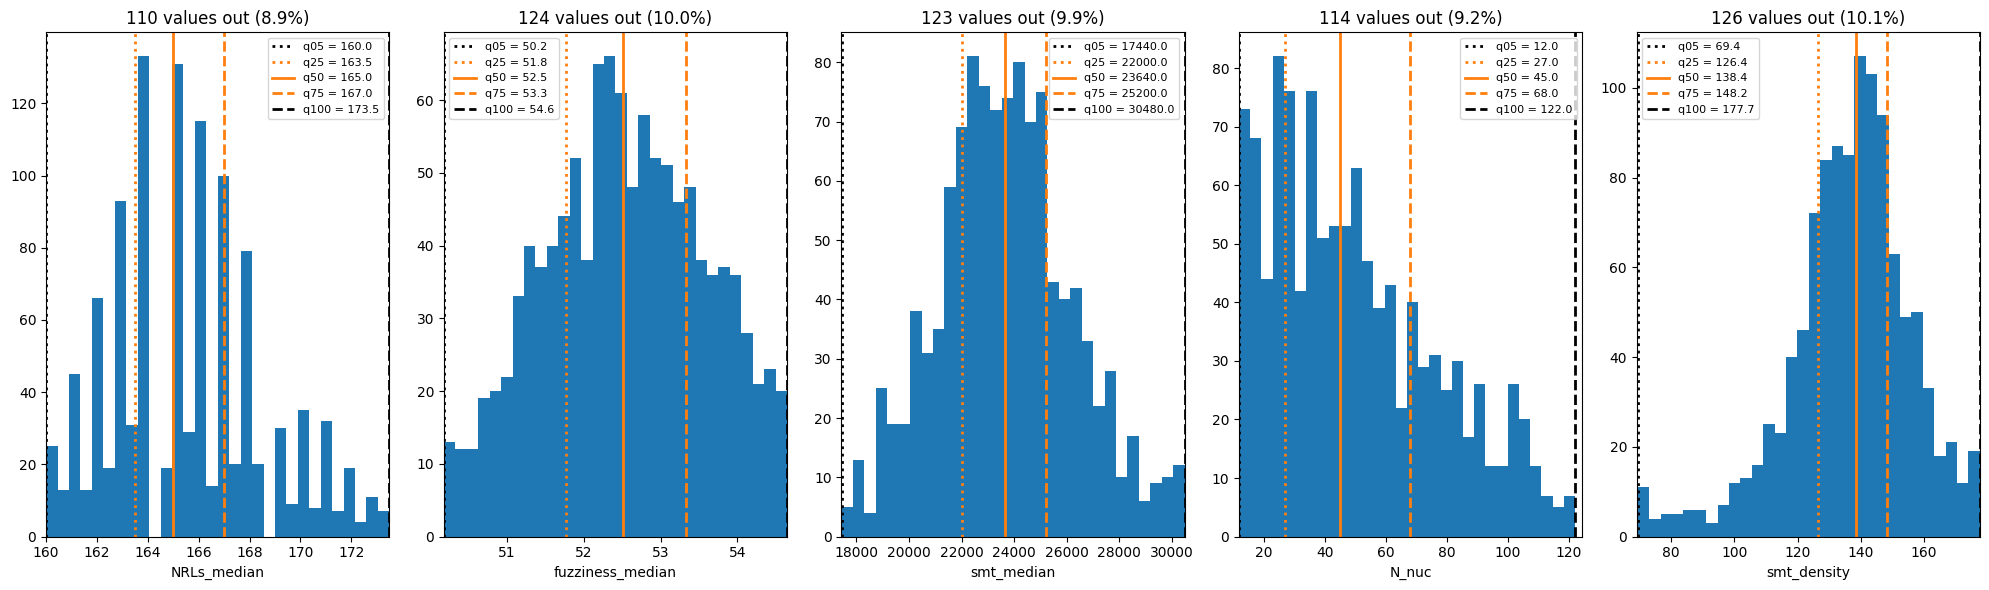

In [10]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import polars as pl


# ── DataFrames ──────────────────────────────────────────────────────────────────

# CARs
df_CARs_NUCLEO = pl.read_parquet("df_CARs_NUCLEO.parquet")
print(df_CARs_NUCLEO)



# ── Prelimenary Analysis ──────────────────────────────────────────────────────

fig, axes = plt.subplots(figsize=(20, 6), ncols=5, nrows=1)

columns     = ["NRLs_median", "fuzziness_median", "smt_median", "N_nuc", "smt_density"]
quartiles   = []

for ax, col in zip(axes, columns):

    # Suppression des NaN / inf
    values = df_CARs_NUCLEO[col].to_numpy()
    values = values[np.isfinite(values)]

    # Conservation des 90 % centraux
    vmin, vmax = np.percentile(values, [5, 95])
    values_plot = values[(values >= vmin) & (values <= vmax)]

    n_removed = len(values) - len(values_plot)

    # Quartiles
    q25, q50, q75 = np.percentile(values_plot, [25, 50, 75])
    q05, q95 = np.min(values_plot), np.max(values_plot)
    quartiles.append({
        "value": col,
        "q05": q05,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "q95": q95,
    })

    # Histogramme
    ax.hist(values_plot, bins=30)
    ax.set_xlim(vmin, vmax)

    # Quartiles
    ax.axvline(q05, color="black", linestyle=":", linewidth=2, label=f"q05 = {q05:.1f}")
    ax.axvline(q25, color="tab:orange", linestyle=":", linewidth=2, label=f"q25 = {q25:.1f}")
    ax.axvline(q50, color="tab:orange", linestyle="-", linewidth=2, label=f"q50 = {q50:.1f}")
    ax.axvline(q75, color="tab:orange", linestyle="--", linewidth=2, label=f"q75 = {q75:.1f}")
    ax.axvline(q95, color="black", linestyle="--", linewidth=2, label=f"q100 = {q95:.1f}")

    # P
    ax.set_xlabel(col)
    ax.set_title(f"{n_removed} values out ({100*n_removed/len(values):.1f}%)")
    ax.legend(fontsize=8)

df_quartiles = pl.DataFrame(quartiles)
plt.tight_layout()
plt.show()

In [ ]:
def filter_DataFrame_by_quartiles(
    df_data: pl.DataFrame, 
    df_quartiles: pl.DataFrame,
    value: str,
    quarter: int
) -> pl.DataFrame:
    
    # Security
    if value not in df_quartiles["value"].to_list():
        raise ValueError(f"You set value = {value} while it needs to be in {df_quartiles['value'].to_list()}")
    if quarter not in [1, 2, 3, 4]:
        raise ValueError(f"You set quarter = {quarter} while it needs to be in [1, 2, 3, 4]")
    
    # Selecting row (df_quartiles already shutted down below 5% and above 95%)
    row = df_quartiles.row(by_predicate=(pl.col("value") == value)) # Taking the row
    vmin, vmax = row[quarter], row[quarter+1]                       # Corresponding values

    # Filtering Values
    if quarter == 4:
        df_out = df_data.filter((pl.col(value) >= vmin) & (pl.col(value) <= vmax))
    else:
        df_out = df_data.filter((pl.col(value) >= vmin) & (pl.col(value) < vmax))

    return df_out


def get_quartile_bounds(df_quartiles: pl.DataFrame, value: str, quarter: int) -> tuple[float, float]:
    cols = ["q0", "q25", "q50", "q75", "q100"]
    row = df_quartiles.filter(pl.col("value") == value).row(0, named=True)
    vmin = row[cols[quarter - 1]]
    vmax = row[cols[quarter]]
    return vmin, vmax


filter_DataFrame_by_quartiles(
    df_data = df_CARs_NUCLEO,
    df_quartiles = df_quartiles,
    value = "N_nuc",
    quarter = 3
)

car_idx,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2,smt_pos,smt_value,fuzziness_score,NRLs,NRLs_median,fuzziness_median,smt_median,N_nuc,smt_density
u32,str,f64,f64,f64,str,f64,f64,f64,list[f64],list[f64],list[f64],list[f64],f64,f64,f64,u32,f64
3,"""chrI""",65253.0,65253.0,35.773094,"""chrI""",74508.0,74508.0,13.379583,"[65288.0, 65513.0, … 74410.0]","[30960.0, 27120.0, … 32400.0]","[55.175528, 54.158252, … 50.141691]","[225.0, 233.0, … 185.0]",162.0,55.314382,17040.0,52,97.832523
9,"""chrI""",137151.0,137151.0,34.139674,"""chrI""",147778.0,147778.0,179.868668,"[137240.0, 137421.0, … 147614.0]","[28240.0, 26080.0, … 38160.0]","[51.969889, 52.937233, … 52.610529]","[181.0, 157.0, … 195.0]",166.0,53.907634,26080.0,56,131.754964
31,"""chrII""",133696.0,133696.0,20.377044,"""chrII""",142201.0,142201.0,10.050608,"[133736.0, 133911.0, … 142027.0]","[23600.0, 6240.0, … 11040.0]","[49.304918, 64.614815, … 56.502826]","[175.0, 154.0, … 161.0]",165.0,55.86299,15800.0,50,95.586126
32,"""chrII""",142201.0,142201.0,10.050608,"""chrII""",150368.0,150368.0,58.067758,"[142234.0, 142352.0, … 150362.0]","[12080.0, 23440.0, … 21360.0]","[59.438898, 52.315317, … 56.428639]","[118.0, 158.0, … 157.0]",160.0,53.357094,22120.0,50,138.55761
33,"""chrII""",150368.0,150368.0,58.067758,"""chrII""",162373.0,162373.0,18.39124,"[150528.0, 150688.0, … 162247.0]","[32000.0, 22320.0, … 36160.0]","[51.440675, 54.633714, … 45.899538]","[160.0, 181.0, … 181.0]",167.0,51.5644,24960.0,67,149.151187
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1228,"""chrXVI""",796044.0,796044.0,37.741897,"""chrXVI""",804332.0,804332.0,55.026651,"[796094.0, 796273.0, … 804268.0]","[22640.0, 19040.0, … 34640.0]","[56.536426, 56.9328, … 54.445751]","[179.0, 181.0, … 226.0]",163.5,53.197058,23600.0,49,141.718147
1231,"""chrXVI""",815656.0,815656.0,13.202129,"""chrXVI""",824935.0,824935.0,30.168876,"[815668.0, 815821.0, … 824805.0]","[22960.0, 22160.0, … 29520.0]","[55.003081, 56.466777, … 51.962526]","[153.0, 164.0, … 156.0]",159.0,54.694563,19880.0,54,124.547904
1234,"""chrXVI""",835682.0,835682.0,24.798935,"""chrXVI""",850074.0,850074.0,11.624188,"[835812.0, 835960.0, … 847031.0]","[25600.0, 27680.0, … 3760.0]","[55.266768, 53.147694, … 50.944424]","[148.0, 189.0, … 125.0]",165.5,54.022554,19760.0,51,63.790995


In [ ]:
# ── Checking the conservation of Data ──────────────────────────────────────────────────────────────────
QUARTERS  = [1, 2, 3, 4]
test_len  = 0

for q in QUARTERS:
    df_single = filter_DataFrame_by_quartiles(
        df_data = df_CARs_NUCLEO,
        df_quartiles = df_quartiles,
        value = "smt_median",
        quarter = q
    )

    test_len += len(df_single)

print(test_len + 100)

1217


INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrI', 'chrI'): 1
INFO:coolpuppy:('chrIII', 'chrIII'): 2
INFO:coolpuppy:('chrX', 'chrX'): 5
INFO:coolpuppy:('chrVIII', 'chrVIII'): 6
INFO:coolpuppy:('chrIX', 'chrIX'): 4
INFO:coolpuppy:('chrV', 'chrV'): 3
INFO:coolpuppy:('chrXII', 'chrXII'): 5
INFO:coolpuppy:('chrII', 'chrII'): 4
INFO:coolpuppy:('chrXIII', 'chrXIII'): 3
INFO:coolpuppy:('chrXIV', 'chrXIV'): 4
INFO:coolpuppy:('chrXI', 'chrXI'): 2
INFO:coolpuppy:('chrXVI', 'chrXVI'): 7
INFO:coolpuppy:('chrVII', 'chrVII'): 4
INFO:coolpuppy:('chrXV', 'chrXV'): 3
INFO:coolpuppy:('chrIV', 'chrIV'): 8
INFO:coolpuppy:Total number of piled up windows: 61
INFO:coolpuppy:('chrI', 'chrI'): 2
INFO:coolpuppy:('chrIX', 'chrIX'): 3
INFO:coolpuppy:('chrV', 'chrV'): 3
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrIII', 'chrIII'): 2
INFO:coolpuppy:('chrVIII', 'chrVIII'): 3
INFO:coolpuppy:('chrII', 'chrII'): 7
INFO:coolpuppy:('chrX', 'chrX'): 7
INFO:coolpuppy:('chrXVI', 'chrXVI'): 8
INFO:co

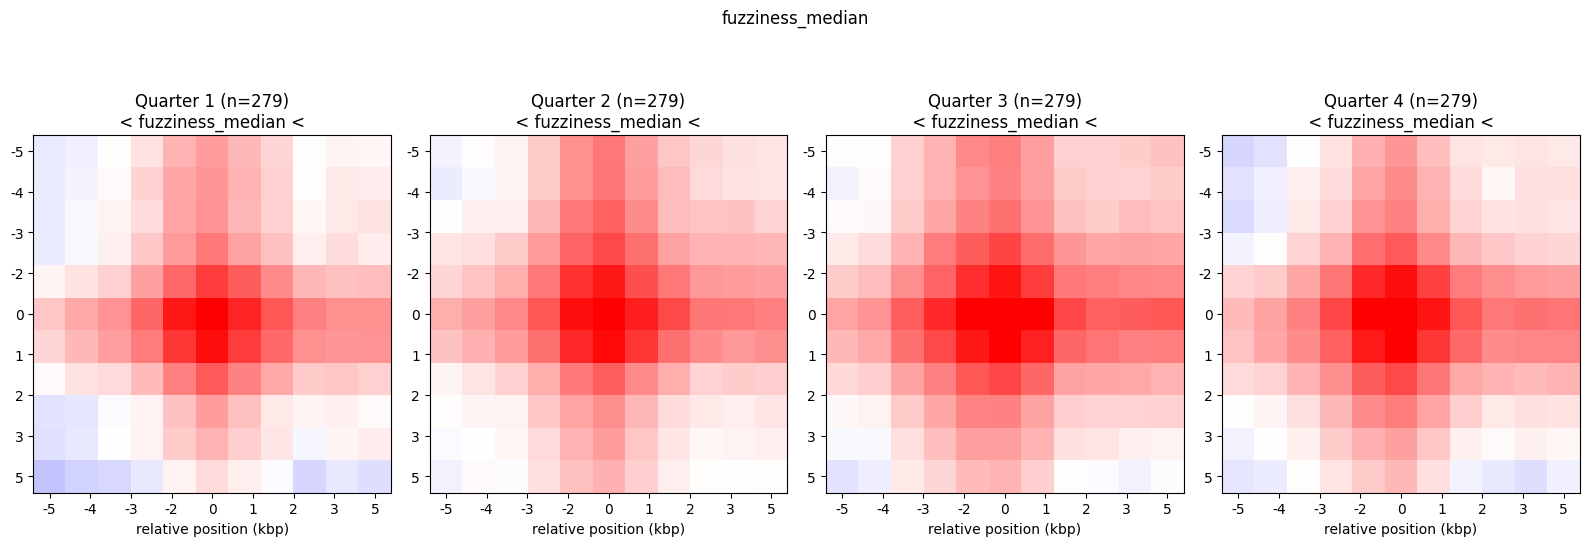

In [ ]:
 # ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Préparation commune (ne dépend pas du quartile) ──────────────────────────
RESOLUTION  = 1000
FLANK       = 5_000 
ROOT        = "/home/nicolas/Documents/Workspace/nucleo/"


QUARTERS = [1, 2, 3, 4]
VALUE    =  "fuzziness_median"   #"N_nuc"


clr = cooler.Cooler(
    ROOT +  "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)

# ── Calls for plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(figsize=(16, 6), ncols=len(QUARTERS), nrows=1)

for axi, quarter in zip(axes, QUARTERS):
    df_single = filter_DataFrame_by_quartiles(
        df_data=df_CARs_NUCLEO,
        df_quartiles=df_quartiles,
        value=VALUE,
        quarter=quarter,
    ).to_pandas()

    pup = cpp_pileup(
        clr,
        df_single,
        features_format="bedpe",
        flank=FLANK,
        view_df=view_df,
        expected_df=cvd,
        expected_value_col="count.avg.smoothed",
        clr_weight_name=None,
        nproc=8,
    )

    # ── Plot sur le sous-graphique correspondant ─────────────────────────────
    mtx = pup.loc[0, 'data']
    im = axi.imshow(
        np.log2(mtx),
        cmap='bwr',
        vmin=-1,
        vmax=1,
        interpolation='none'
    )

    ticks_pixels = np.linspace(0, FLANK * 2 // RESOLUTION, 9)
    ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * RESOLUTION // 1000).astype(int)
    axi.set(
        xticks=ticks_pixels,
        xticklabels=ticks_kbp,
        yticks=ticks_pixels,
        yticklabels=ticks_kbp,
        xlabel='relative position (kbp)',
        title=(
            f"Quarter {quarter} (n={len(df_single)})\n"
            f" < {VALUE} < "
        ),
    )

plt.tight_layout()
plt.show()

INFO:root:creating a Pool of 8 workers


NRLs_median | Q1 | 274 loci | 16 chromosomes
160.00 < NRLs_median < 163.50


INFO:coolpuppy:('chrI', 'chrI'): 2
INFO:coolpuppy:('chrIII', 'chrIII'): 1
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrIX', 'chrIX'): 2
INFO:coolpuppy:('chrVIII', 'chrVIII'): 2
INFO:coolpuppy:('chrII', 'chrII'): 4
INFO:coolpuppy:('chrX', 'chrX'): 7
INFO:coolpuppy:('chrV', 'chrV'): 3
INFO:coolpuppy:('chrVII', 'chrVII'): 10
INFO:coolpuppy:('chrXI', 'chrXI'): 5
INFO:coolpuppy:('chrXIV', 'chrXIV'): 5
INFO:coolpuppy:('chrXII', 'chrXII'): 6
INFO:coolpuppy:('chrXVI', 'chrXVI'): 6
INFO:coolpuppy:('chrIV', 'chrIV'): 11
INFO:coolpuppy:('chrXIII', 'chrXIII'): 2
INFO:coolpuppy:('chrXV', 'chrXV'): 4
INFO:coolpuppy:Total number of piled up windows: 71


NRLs_median | Q2 | 183 loci | 16 chromosomes
163.50 < NRLs_median < 165.00


INFO:coolpuppy:('chrI', 'chrI'): 1
INFO:coolpuppy:('chrIII', 'chrIII'): 1
INFO:coolpuppy:('chrIX', 'chrIX'): 3
INFO:coolpuppy:('chrX', 'chrX'): 2
INFO:coolpuppy:('chrII', 'chrII'): 4
INFO:coolpuppy:('chrVIII', 'chrVIII'): 4
INFO:coolpuppy:('chrXIII', 'chrXIII'): 5
INFO:coolpuppy:('chrXII', 'chrXII'): 9
INFO:coolpuppy:('chrV', 'chrV'): 2
INFO:coolpuppy:('chrXI', 'chrXI'): 5
INFO:coolpuppy:('chrXIV', 'chrXIV'): 3
INFO:coolpuppy:('chrXVI', 'chrXVI'): 9
INFO:coolpuppy:('chrXV', 'chrXV'): 7
INFO:coolpuppy:('chrVII', 'chrVII'): 12
INFO:coolpuppy:('chrIV', 'chrIV'): 10
INFO:coolpuppy:Total number of piled up windows: 77


...

INFO:coolpuppy:('chrI', 'chrI'): 1
INFO:coolpuppy:('chrVI', 'chrVI'): 3
INFO:coolpuppy:('chrIII', 'chrIII'): 1
INFO:coolpuppy:('chrIX', 'chrIX'): 5
INFO:coolpuppy:('chrXI', 'chrXI'): 11
INFO:coolpuppy:('chrX', 'chrX'): 9
INFO:coolpuppy:('chrVIII', 'chrVIII'): 2
INFO:coolpuppy:('chrXIV', 'chrXIV'): 10
INFO:coolpuppy:('chrXII', 'chrXII'): 12
INFO:coolpuppy:('chrV', 'chrV'): 4
INFO:coolpuppy:('chrXIII', 'chrXIII'): 7
INFO:coolpuppy:('chrVII', 'chrVII'): 10
INFO:coolpuppy:('chrXVI', 'chrXVI'): 10
INFO:coolpuppy:('chrXV', 'chrXV'): 9
INFO:coolpuppy:('chrII', 'chrII'): 7
INFO:coolpuppy:('chrIV', 'chrIV'): 18
INFO:coolpuppy:Total number of piled up windows: 119


smt_density | Q3 | 280 loci | 16 chromosomes
138.39 < smt_density < 148.18


INFO:coolpuppy:('chrIII', 'chrIII'): 5
INFO:coolpuppy:('chrVI', 'chrVI'): 2
INFO:coolpuppy:('chrXI', 'chrXI'): 6
INFO:coolpuppy:('chrIX', 'chrIX'): 2
INFO:coolpuppy:('chrX', 'chrX'): 6
INFO:coolpuppy:('chrII', 'chrII'): 9
INFO:coolpuppy:('chrVIII', 'chrVIII'): 4
INFO:coolpuppy:('chrV', 'chrV'): 2
INFO:coolpuppy:('chrXVI', 'chrXVI'): 12
INFO:coolpuppy:('chrXV', 'chrXV'): 9
INFO:coolpuppy:('chrVII', 'chrVII'): 9
INFO:coolpuppy:('chrXIV', 'chrXIV'): 6
INFO:coolpuppy:('chrXII', 'chrXII'): 8
INFO:coolpuppy:('chrXIII', 'chrXIII'): 5
INFO:coolpuppy:('chrIV', 'chrIV'): 14
INFO:coolpuppy:Total number of piled up windows: 99


smt_density | Q4 | 280 loci | 16 chromosomes
148.18 < smt_density < 177.69


INFO:coolpuppy:('chrIX', 'chrIX'): 1
INFO:coolpuppy:('chrI', 'chrI'): 3
INFO:coolpuppy:('chrVIII', 'chrVIII'): 5
INFO:coolpuppy:('chrX', 'chrX'): 2
INFO:coolpuppy:('chrXIV', 'chrXIV'): 2
INFO:coolpuppy:('chrXI', 'chrXI'): 3
INFO:coolpuppy:('chrXII', 'chrXII'): 5
INFO:coolpuppy:('chrVII', 'chrVII'): 5
INFO:coolpuppy:('chrXV', 'chrXV'): 4
INFO:coolpuppy:('chrXVI', 'chrXVI'): 1
INFO:coolpuppy:('chrXIII', 'chrXIII'): 3
INFO:coolpuppy:('chrII', 'chrII'): 4
INFO:coolpuppy:('chrIV', 'chrIV'): 3
INFO:coolpuppy:Total number of piled up windows: 41


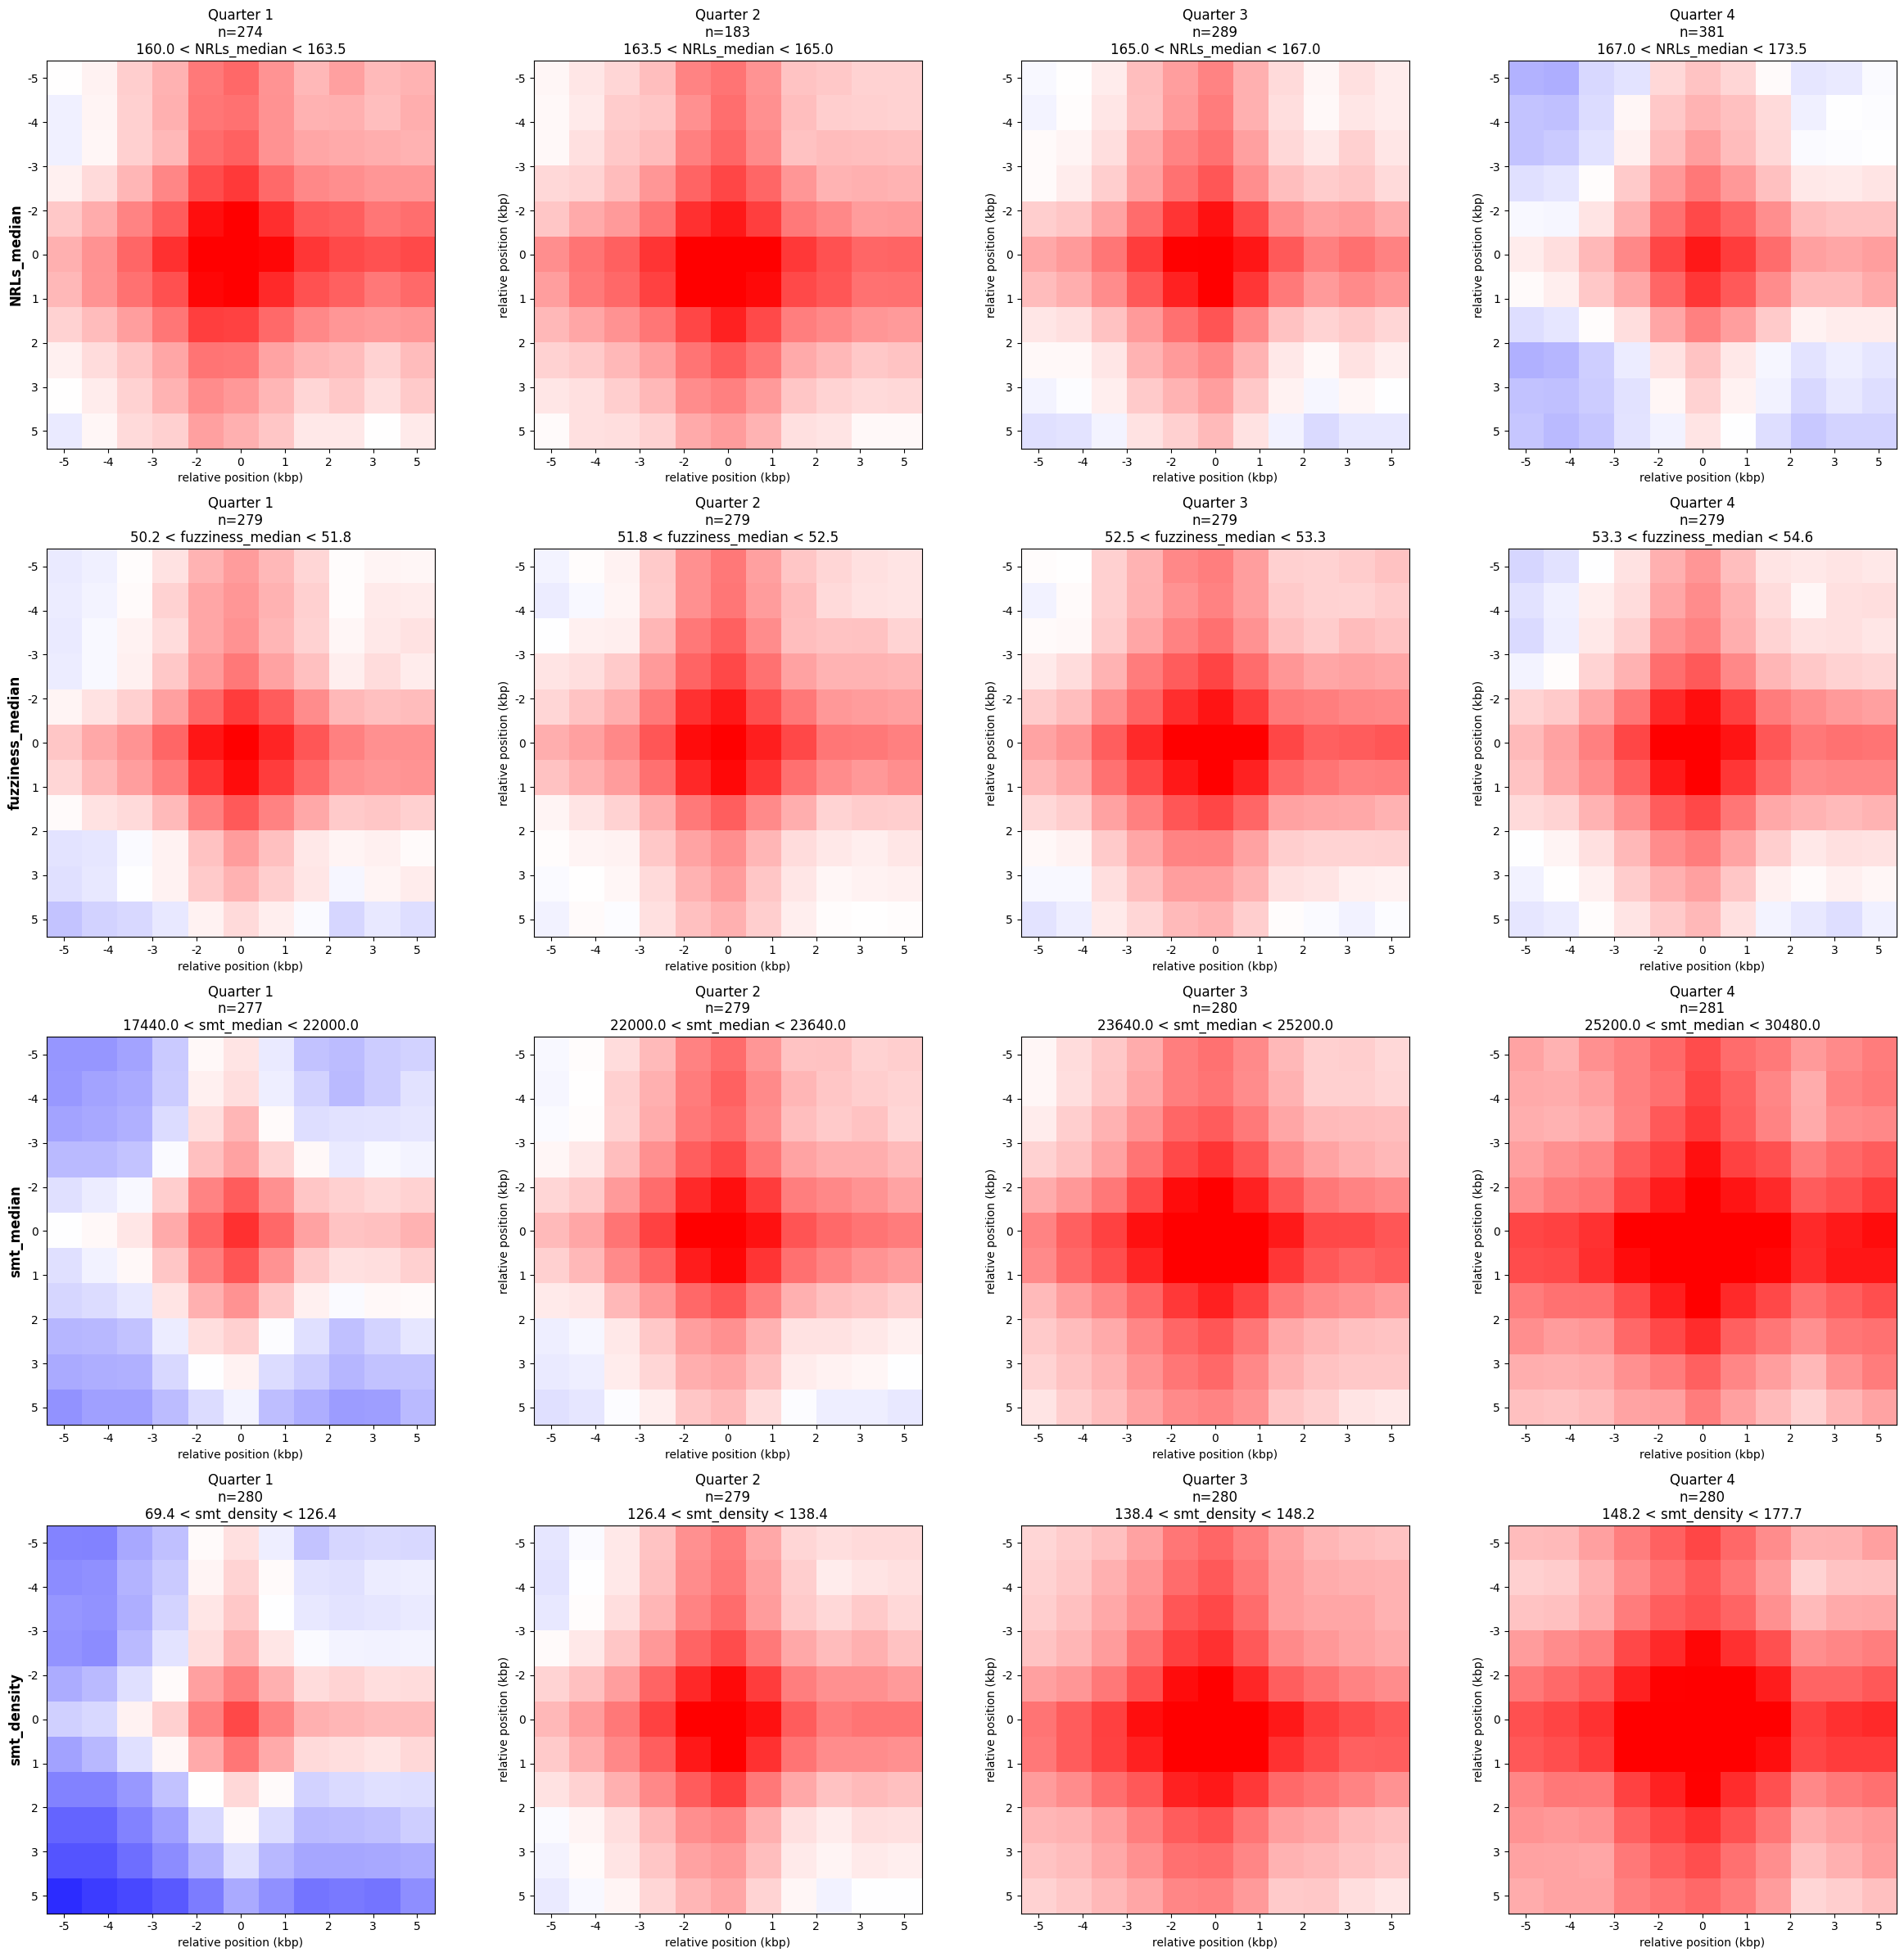

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Paramètres ───────────────────────────────────────────────────────────────

RESOLUTION = 1000
FLANK      = 5_000
ROOT       = "/home/nicolas/Documents/Workspace/nucleo/"

QUARTERS = [1, 2, 3, 4]
VALUES   = ["NRLs_median", "fuzziness_median", "smt_median", "smt_density"]



# ── Chargement cooler ────────────────────────────────────────────────────────

clr = cooler.Cooler(
    ROOT + "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)


view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})


# ── Expected matrix ──────────────────────────────────────────────────────────

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8,
)



# ── Fonctions utilitaires ────────────────────────────────────────────────────


QUARTILE_COLS = [
    "q0",
    "q25",
    "q50",
    "q75",
    "q100"
]


def get_quartile_bounds(df_quartiles, value, quarter):
    """
    Retourne les bornes du quartile demandé.

    quarter:
        1 -> q05-q25
        2 -> q25-q50
        3 -> q50-q75
        4 -> q75-q95
    """

    row = (
        df_quartiles
        .filter(pl.col("value") == value)
        .row(0, named=True)
    )

    quartile_cols = [
        "q05",
        "q25",
        "q50",
        "q75",
        "q95"
    ]

    return (
        float(row[quartile_cols[quarter - 1]]),
        float(row[quartile_cols[quarter]])
    )



def match_chromosome(chrom, cooler_chroms):
    """
    Harmonise le format chromosome BEDPE/cooler.
    """

    chrom = str(chrom)

    # Déjà compatible
    if chrom in cooler_chroms:
        return chrom


    # Ajout chr
    if "chr" + chrom in cooler_chroms:
        return "chr" + chrom


    # Retrait chr
    if chrom.startswith("chr") and chrom[3:] in cooler_chroms:
        return chrom[3:]


    raise ValueError(
        f"Chromosome {chrom} incompatible.\n"
        f"Exemple cooler : {list(cooler_chroms)[:10]}"
    )



# ── Création figure ──────────────────────────────────────────────────────────


nrows = len(VALUES)
ncols = len(QUARTERS)


fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6*ncols, 6*nrows),
    squeeze=False
)



# ── Boucle quartiles ─────────────────────────────────────────────────────────


for row_axes, value in zip(axes, VALUES):


    for ax, quarter in zip(row_axes, QUARTERS):


        # -------------------------------------------------------------
        # Filtrage des contacts
        # -------------------------------------------------------------

        df_single = filter_DataFrame_by_quartiles(
            df_data=df_CARs_NUCLEO,
            df_quartiles=df_quartiles,
            value=value,
            quarter=quarter,
        ).to_pandas()



        # -------------------------------------------------------------
        # Harmonisation chromosomes
        # -------------------------------------------------------------

        cooler_chroms = set(clr.chromnames)


        df_single["chrom1"] = df_single["chrom1"].apply(
            lambda x: match_chromosome(
                x,
                cooler_chroms
            )
        )

        df_single["chrom2"] = df_single["chrom2"].apply(
            lambda x: match_chromosome(
                x,
                cooler_chroms
            )
        )


        common = (
            set(df_single["chrom1"])
            .intersection(cooler_chroms)
        )


        print(
            f"{value} | Q{quarter} | "
            f"{len(df_single)} loci | "
            f"{len(common)} chromosomes"
        )



        # -------------------------------------------------------------
        # Bornes quartiles
        # -------------------------------------------------------------

        vmin, vmax = get_quartile_bounds(
            df_quartiles,
            value,
            quarter
        )


        print(
            f"{vmin:.2f} < {value} < {vmax:.2f}"
        )



        # -------------------------------------------------------------
        # Pileup
        # -------------------------------------------------------------

        pup = cpp_pileup(
            clr,
            df_single,
            features_format="bedpe",
            flank=FLANK,
            view_df=view_df,
            expected_df=cvd,
            expected_value_col="count.avg.smoothed",
            clr_weight_name=None,
            nproc=8,
        )



        # -------------------------------------------------------------
        # Affichage
        # -------------------------------------------------------------

        mtx = pup.loc[0, "data"]


        ax.imshow(
            np.log2(mtx),
            cmap="bwr",
            vmin=-1,
            vmax=1,
            interpolation="none"
        )


        ticks_pixels = np.linspace(
            0,
            FLANK * 2 // RESOLUTION,
            9
        )


        ticks_kbp = (
            (ticks_pixels - ticks_pixels[-1]/2)
            * RESOLUTION
            // 1000
        ).astype(int)



        ax.set(
            xticks=ticks_pixels,
            xticklabels=ticks_kbp,
            yticks=ticks_pixels,
            yticklabels=ticks_kbp,
            xlabel="relative position (kbp)",
            ylabel="relative position (kbp)",
            title=(
                f"Quarter {quarter}\n n={len(df_single)}\n"
                f"{vmin:.1f} < {value} < {vmax:.1f}"
            )
        )


    row_axes[0].set_ylabel(
        value,
        fontsize=12,
        fontweight="bold"
    )



plt.tight_layout()
plt.show()

# HiC Map

/tmp/ipykernel_110923/3395831196.py:4: RuntimeWarning: divide by zero encountered in log2
  np.log2(mtx_2),


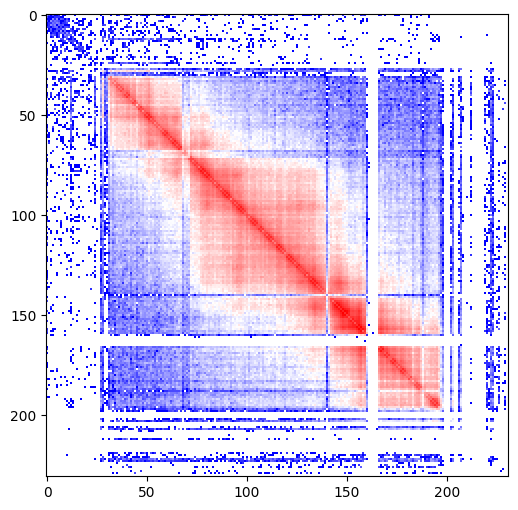

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx_2=clr.matrix(balance=False).fetch("chrI")
im=ax.imshow(
    np.log2(mtx_2),
    cmap='bwr',
    # vmin=-1,
    # vmax=1,
interpolation='none')

# .